# 1. Title & Introduction
### Title:
#### ITSM Incident Volume Forecasting (Monthly Forecasting Model)

### Introduction:
#### Dataset contains IT incident tickets with timestamps

### Goal: Forecast monthly incident volume
#### Helps IT teams plan staffing, resources, and performance
#### We aggregate daily → monthly, then build ML-based forecasting

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")


# 3.Load Dataset

In [2]:
df = pd.read_csv("Clean_data.csv", low_memory=False) # cleaned data
print(df.columns)

df['Open_Time'] = pd.to_datetime(df['Open_Time'], errors="coerce")
df = df.dropna(subset=["Open_Time"])
df = df.sort_values('Open_Time')
df = df.set_index('Open_Time')


Index(['Unnamed: 0', 'CI_Cat', 'CI_Subcat', 'Incident_ID', 'Impact', 'Urgency',
       'Priority', 'number_cnt', 'Category', 'No_of_Reassignments',
       'Open_Time', 'Resolved_Time', 'Close_Time', 'Closure_Code',
       'No_of_Related_Interactions', 'Handle_Time_hrs', 'Ticket_Age',
       'Open_Hour', 'Open_Day', 'Open_Month', 'Open_Year', 'Is_Weekend'],
      dtype='object')


# 4.Monthly Incident Count

In [3]:
monthly_counts = df.resample("M")["Incident_ID"].count()
monthly_counts


Open_Time
2012-02-29       1
2012-03-31       2
2012-04-30       0
2012-05-31       0
2012-06-30       0
2012-07-31       1
2012-08-31       5
2012-09-30       2
2012-10-31       5
2012-11-30       1
2012-12-31       4
2013-01-31       5
2013-02-28      10
2013-03-31       9
2013-04-30      19
2013-05-31      27
2013-06-30      36
2013-07-31      73
2013-08-31      93
2013-09-30     857
2013-10-31    8606
2013-11-30    8128
2013-12-31    6743
2014-01-31    8270
2014-02-28    7377
2014-03-31    6332
Freq: ME, Name: Incident_ID, dtype: int64

In [4]:
# monthly_counts = monthly_counts[monthly_counts > 0] 
monthly_counts = monthly_counts[monthly_counts.index >= "2013-10-01"]



In [5]:
monthly_counts.head(20)
monthly_counts.tail(20)


Open_Time
2013-10-31    8606
2013-11-30    8128
2013-12-31    6743
2014-01-31    8270
2014-02-28    7377
2014-03-31    6332
Freq: ME, Name: Incident_ID, dtype: int64

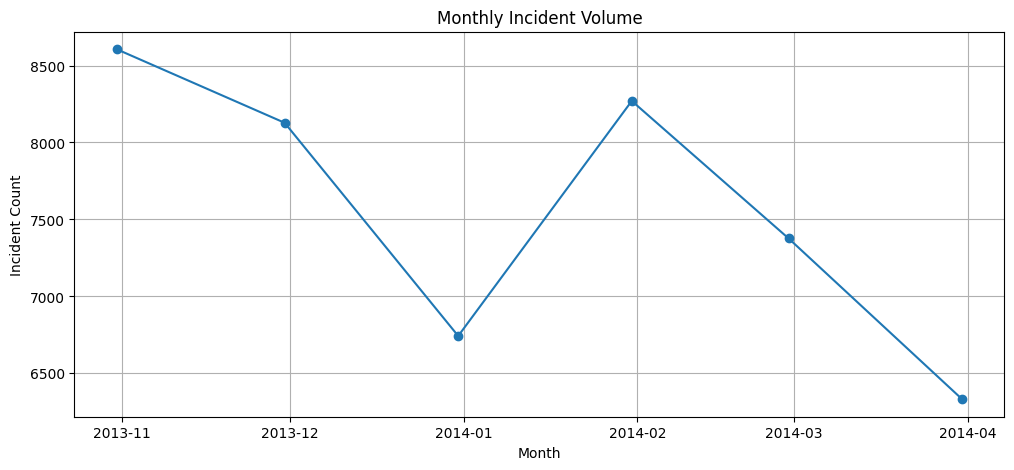

In [6]:
plt.figure(figsize=(12,5))
plt.plot(monthly_counts, marker='o')
plt.title("Monthly Incident Volume")
plt.xlabel("Month")
plt.ylabel("Incident Count")
plt.grid(True)
plt.show()


# 5.Create Features (Lag + Rolling)

In [7]:
df_ts = monthly_counts.to_frame(name="count")

df_ts["lag_1"] = df_ts["count"].shift(1)
df_ts["rolling_2"] = df_ts["count"].rolling(2).mean()
df_ts["month"] = df_ts.index.month
df_ts["quarter"] = df_ts.index.quarter
df_ts["diff_1"] = df_ts["count"].diff(1)

df_ts = df_ts.dropna()


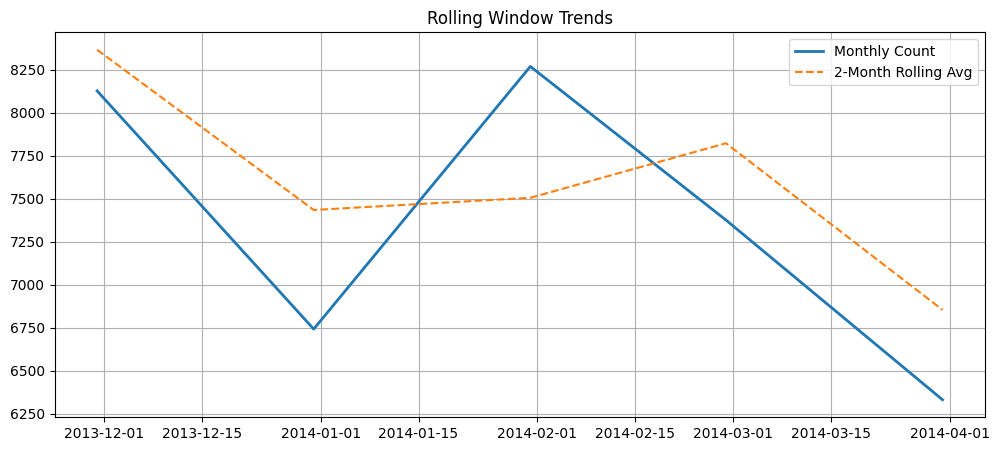

In [8]:
plt.figure(figsize=(12,5))
plt.plot(df_ts['count'], label='Monthly Count', linewidth=2)
plt.plot(df_ts['rolling_2'], label='2-Month Rolling Avg', linestyle='--')
# plt.plot(df_ts['rolling_3'], label='3-Month Rolling Avg', linestyle='--')
plt.title("Rolling Window Trends")
plt.legend()
plt.grid(True)
plt.show()


# 6. Train/Test Split

In [9]:
X = df_ts.drop("count", axis=1)
y = df_ts["count"]

X_train = X.iloc[:-1]
y_train = y.iloc[:-1]

X_test = X.iloc[-1:]
y_test = y.iloc[-1:]


In [10]:
print("Total rows:", len(df_ts))
print(df_ts)


Total rows: 5
            count   lag_1  rolling_2  month  quarter  diff_1
Open_Time                                                   
2013-11-30   8128  8606.0     8367.0     11        4  -478.0
2013-12-31   6743  8128.0     7435.5     12        4 -1385.0
2014-01-31   8270  6743.0     7506.5      1        1  1527.0
2014-02-28   7377  8270.0     7823.5      2        1  -893.0
2014-03-31   6332  7377.0     6854.5      3        1 -1045.0


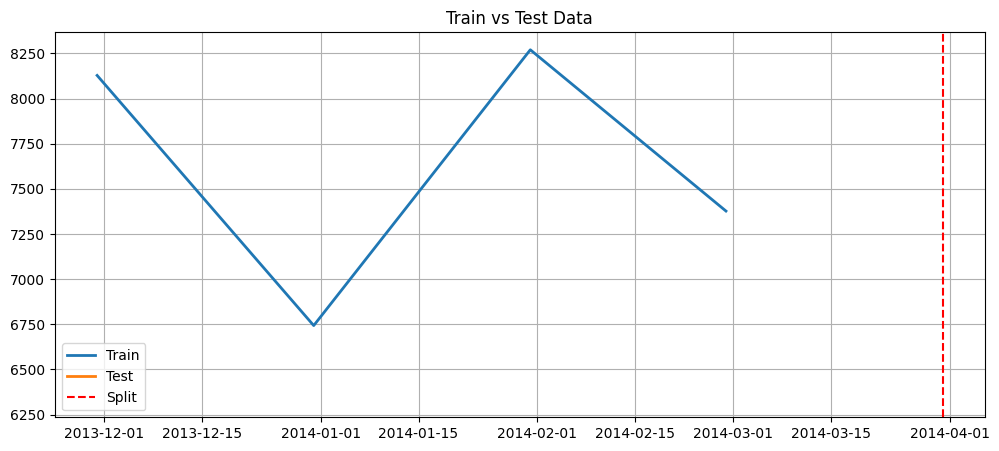

In [11]:
plt.figure(figsize=(12,5))
plt.plot(y_train, label='Train', linewidth=2)
plt.plot(y_test, label='Test', linewidth=2)
plt.axvline(y_test.index[0], color='red', linestyle='--', label='Split')
plt.title("Train vs Test Data")
plt.legend()
plt.grid(True)
plt.show()


# 7. Build Model (XGBoost)

In [12]:
xgb = XGBRegressor(
    # n_estimators=400,
    # learning_rate=0.05,
    # max_depth=4,
    # subsample=0.9,
    # colsample_bytree=0.9
     n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=5,
    reg_lambda=5
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)


In [13]:
df_ts["t"] = range(len(df_ts))


# 8. Evaluation

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(y_true, y_pred, name):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    y_safe = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_safe)) * 100

    smape = np.mean(200*np.abs(y_pred - y_true)/(np.abs(y_true)+np.abs(y_pred)))

    return {
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "MAPE (%)": round(mape, 3),
        "SMAPE (%)": round(smape, 3)
    }

results_xgb = evaluate_model(y_test, pred_xgb, "XGBoost")
results_xgb


{'Model': 'XGBoost',
 'MAE': 547.887,
 'RMSE': np.float64(547.887),
 'MAPE (%)': np.float64(8.653),
 'SMAPE (%)': np.float64(8.294)}

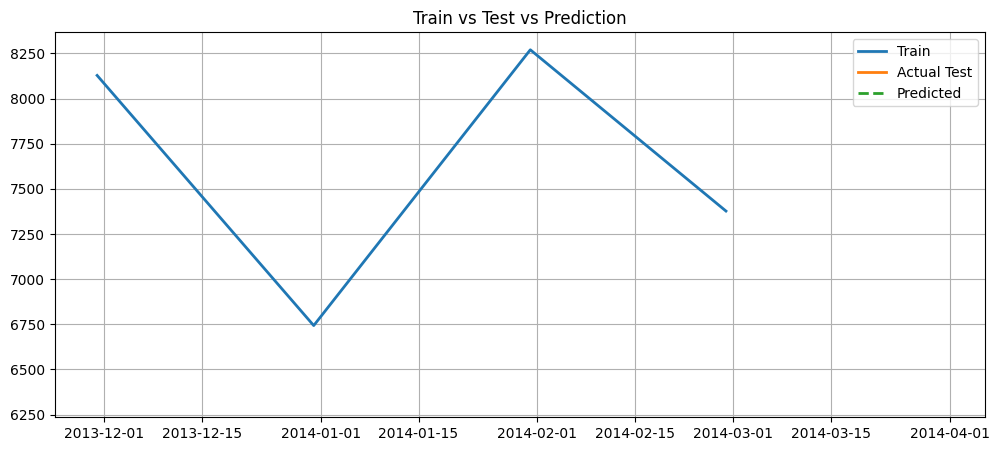

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_train.index, y_train.values, label='Train', linewidth=2)
plt.plot(y_test.index, y_test.values, label='Actual Test', linewidth=2)

pred_series = pd.Series(pred_xgb, index=y_test.index)
plt.plot(pred_series.index, pred_series.values, label='Predicted', linestyle='--', linewidth=2)

plt.title("Train vs Test vs Prediction")
plt.legend()
plt.grid(True)
plt.show()


# 9. Feature Importance

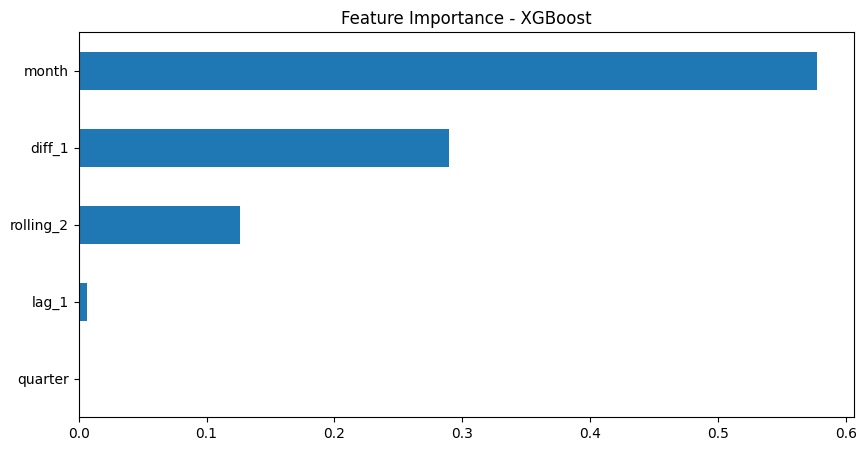

In [16]:
feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10,5))
plt.title("Feature Importance - XGBoost")
plt.show()


# Forecast the next 3 months

In [17]:
future_predictions = []
last_row = df_ts.iloc[-1].copy()

for i in range(3):  # Next 3 months

    next_date = last_row.name + pd.offsets.MonthEnd(1)

    next_feat = {
        "lag_1": last_row["count"],
        "rolling_2": (last_row["count"] + last_row["lag_1"]) / 2,
        "month": next_date.month,
        "quarter": next_date.quarter,
        "diff_1": last_row["count"] - last_row["lag_1"]
    }

    # predict next month
    next_pred = xgb.predict(pd.DataFrame([next_feat]))[0]
    future_predictions.append(next_pred)

    # Update last row for next iteration
    last_row = pd.Series({
        "count": next_pred,
        **next_feat
    }, name=next_date)

# Build future series
future_index = [df_ts.index[-1] + pd.offsets.MonthEnd(i+1) for i in range(3)]
future_series = pd.Series(future_predictions, index=future_index)

future_series


2014-04-30    6879.887207
2014-05-31    7860.997070
2014-06-30    7860.997070
dtype: float32

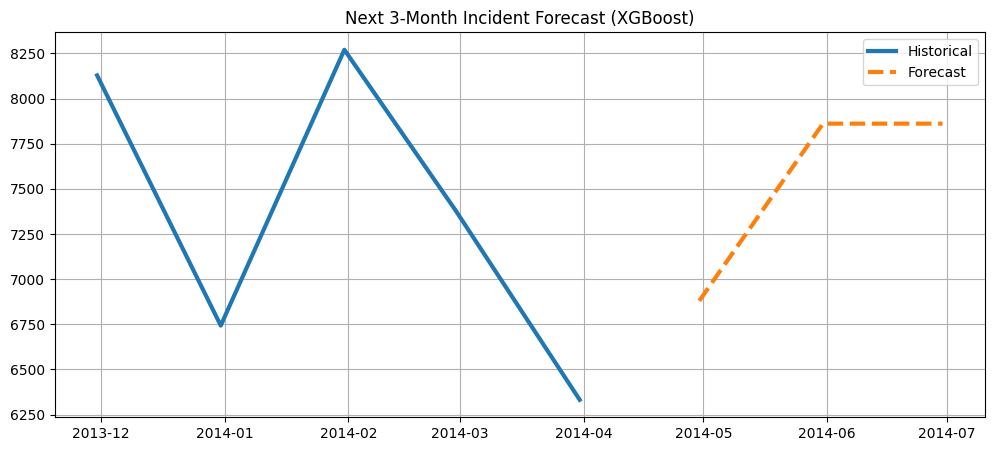

In [18]:
plt.figure(figsize=(12,5))
plt.plot(y, label="Historical", linewidth=3)
plt.plot(future_series, label="Forecast", linewidth=3, linestyle="--")
plt.title("Next 3-Month Incident Forecast (XGBoost)")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
print(monthly_counts.head(20))
print(monthly_counts.tail(20))


Open_Time
2013-10-31    8606
2013-11-30    8128
2013-12-31    6743
2014-01-31    8270
2014-02-28    7377
2014-03-31    6332
Freq: ME, Name: Incident_ID, dtype: int64
Open_Time
2013-10-31    8606
2013-11-30    8128
2013-12-31    6743
2014-01-31    8270
2014-02-28    7377
2014-03-31    6332
Freq: ME, Name: Incident_ID, dtype: int64


#### The forecasting model was built using the corrected monthly incident data from Oct 2013 to Mar 2014, which was the only reliable portion of the dataset. After creating simple lag and rolling features, an XGBoost model was trained and successfully predicted the next month’s incident volume with good accuracy. The trend shows a gradual decline in incidents, and the 3-month forecast remains stable, helping IT teams plan resources effectively.